In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as xp


In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Notes :
    - unessary column : PassengerId, Name , Ticket , Cabin 
    - categorical : Survived , Pclass , Sex , SibSp , Parch , Embarked
    - numericla : Age , Fare 
    - Target : survived 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### Notes : 
    - missing data : Age , Cabin , Embarked 

In [5]:
df.columns = df.columns.str.lower()

In [6]:
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### Data Cleaning 

In [11]:
df.duplicated().sum(0)

np.int64(0)

In [12]:
df.drop(['passengerid','name','ticket','cabin'],axis= 1 ,inplace=True)

In [13]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [14]:
df.dropna(subset = ['embarked'],inplace=True)

In [15]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      0
dtype: int64

In [16]:
df.groupby(['pclass','sex'])['age'].median()

pclass  sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: age, dtype: float64

In [20]:
df['age'] = df.groupby(['pclass', 'sex'])['age'].transform(lambda row: row.fillna(row.median()))

In [21]:
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

In [24]:
df['survived'].value_counts()

survived
0    549
1    340
Name: count, dtype: int64

### function to visualize categorical cols 


In [26]:
def visualize_categorical_cols(df, col):
    print(f'\n------ {col} ------')
    print(df[col].value_counts(normalize=True))

    sns.countplot(x=col, data=df)
    plt.show()



------ survived ------
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64


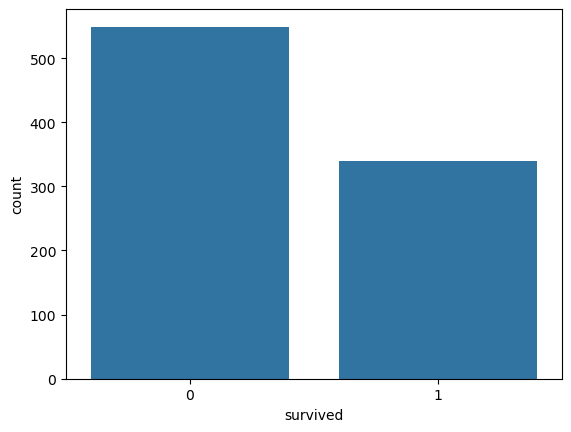


------ pclass ------
pclass
3    0.552306
1    0.240720
2    0.206974
Name: proportion, dtype: float64


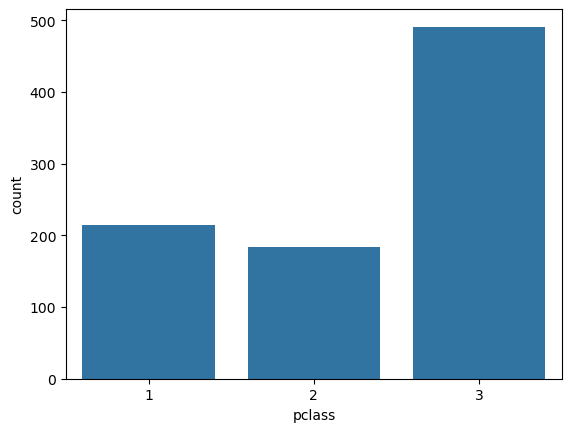


------ sex ------
sex
male      0.649044
female    0.350956
Name: proportion, dtype: float64


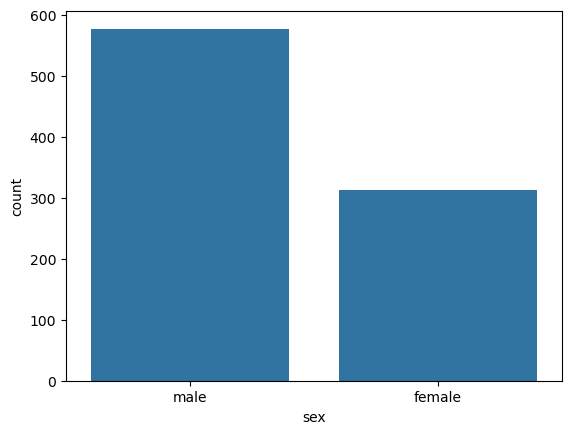


------ sibsp ------
sibsp
0    0.681665
1    0.235096
2    0.031496
4    0.020247
3    0.017998
8    0.007874
5    0.005624
Name: proportion, dtype: float64


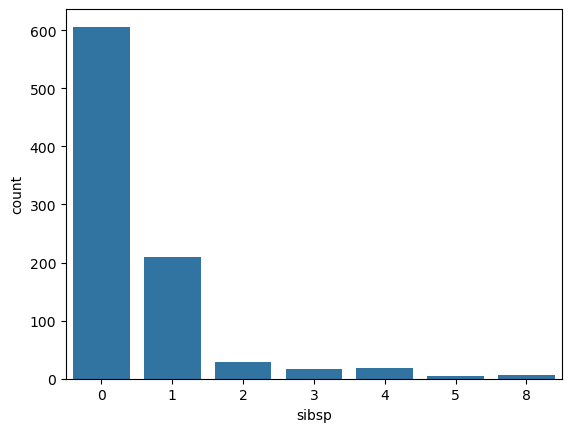


------ parch ------
parch
0    0.760405
1    0.132733
2    0.089989
5    0.005624
3    0.005624
4    0.004499
6    0.001125
Name: proportion, dtype: float64


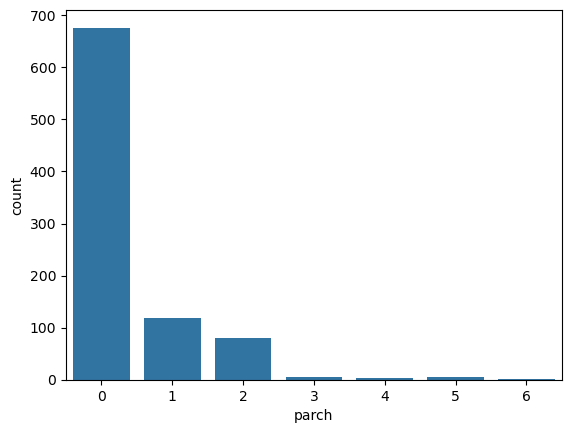


------ embarked ------
embarked
S    0.724409
C    0.188976
Q    0.086614
Name: proportion, dtype: float64


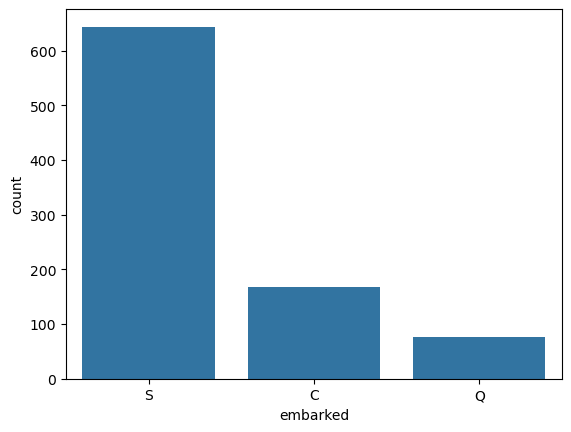

In [29]:
cols = ['survived', 'pclass', 'sex', 'sibsp', 'parch', 'embarked']

for c in cols:
    visualize_categorical_cols(df, c)

#### Notes :
    - 60% no sibsp
    - 76% no parch
    - 72% embarked from s 
    

function to visualize numric cols

In [32]:
def visualize_numric_cols(df, col):
    print(f'\n------ {col} ------')
    print(df[col].value_counts(normalize=True))

    sns.histplot(x=col, data=df)
    plt.show()



------ age ------
age
25.00    0.131609
21.50    0.047244
30.00    0.038245
40.00    0.038245
24.00    0.033746
           ...   
36.50    0.001125
55.50    0.001125
0.92     0.001125
23.50    0.001125
74.00    0.001125
Name: proportion, Length: 89, dtype: float64


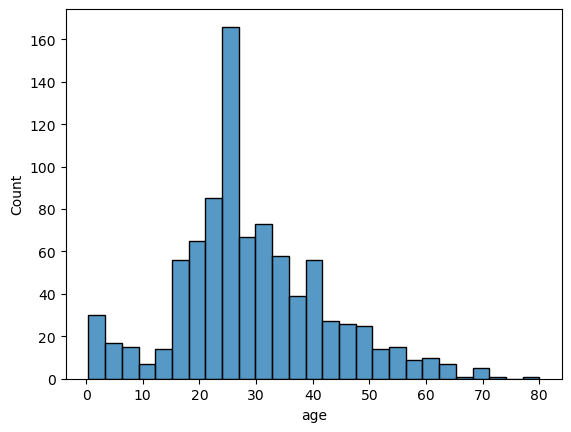


------ fare ------
fare
8.0500     0.048369
13.0000    0.047244
7.8958     0.042745
7.7500     0.038245
26.0000    0.034871
             ...   
35.0000    0.001125
28.5000    0.001125
6.2375     0.001125
14.0000    0.001125
10.5167    0.001125
Name: proportion, Length: 247, dtype: float64


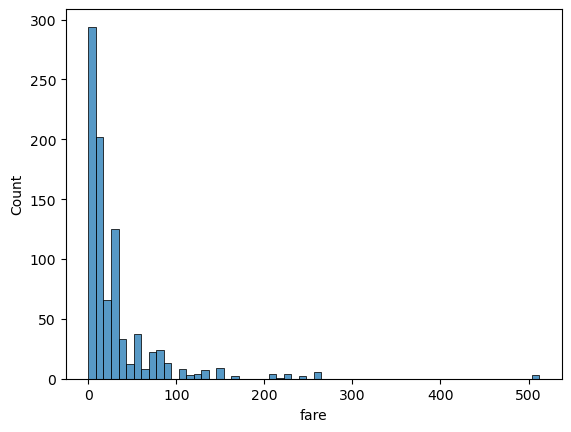

In [33]:
cols = ['age' , 'fare' ]

for c in cols:
    visualize_numric_cols(df, c)

### Notes :
    - majority age : 25
    - age range 15 ,40
    - majority fare 0-->150 

In [34]:
df.groupby('pclass').survived.mean()

pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

<Axes: xlabel='pclass', ylabel='survived'>

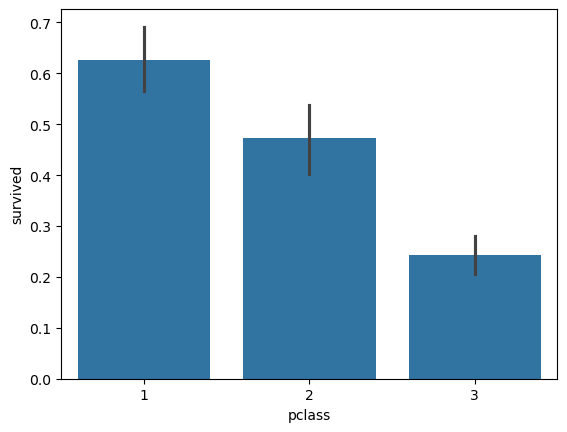

In [35]:
sns.barplot(x='pclass',y = 'survived',data = df)

<Axes: xlabel='pclass', ylabel='count'>

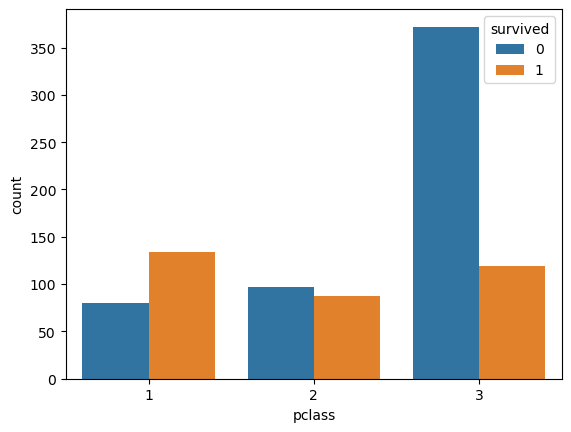

In [37]:
sns.countplot(x='pclass',hue = 'survived',data = df)

### Notes: 
    - 62% class 1 survived
    -47% class 2 survived
    -24% class 3 survived 


In [39]:
def visualize_rate_cols(df, col):
    print(f'\n------ {col} ------')
    print(df.groupby(col).survived.mean())

    sns.barplot(x=col, y='survived', data=df)
    plt.axhline(df.survived.mean(), linestyle='--')
    plt.show()


------ pclass ------
pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64


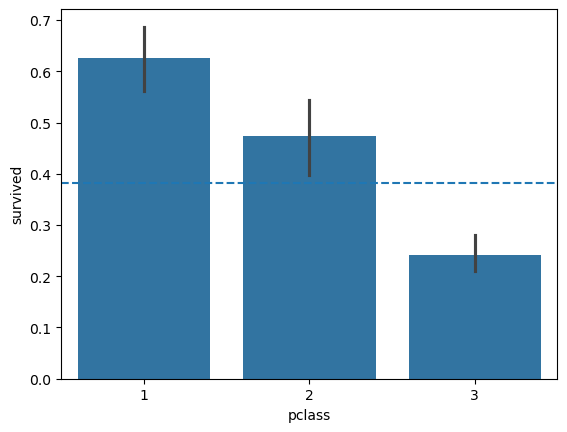


------ sex ------
sex
female    0.740385
male      0.188908
Name: survived, dtype: float64


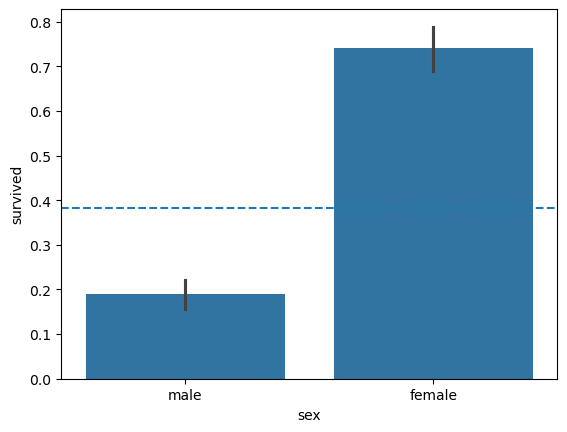


------ sibsp ------
sibsp
0    0.343234
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: survived, dtype: float64


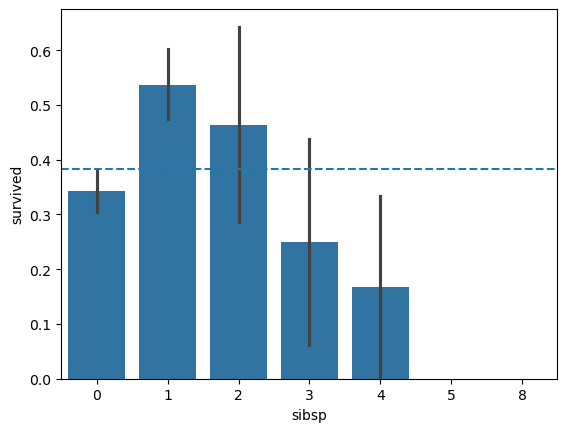


------ parch ------
parch
0    0.341716
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: survived, dtype: float64


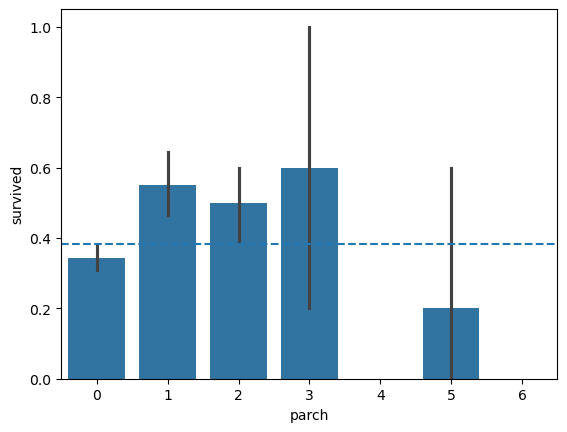


------ embarked ------
embarked
C    0.553571
Q    0.389610
S    0.336957
Name: survived, dtype: float64


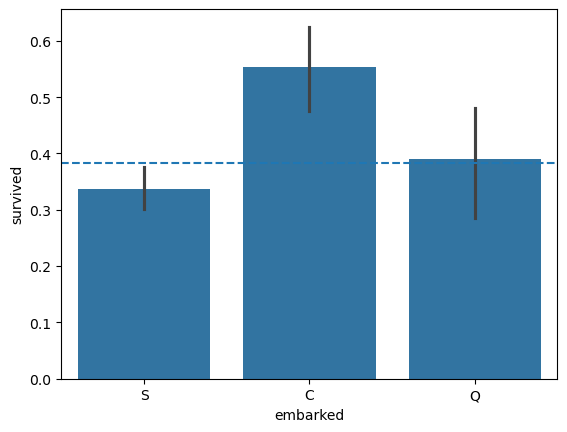

In [41]:
cols = ['pclass', 'sex', 'sibsp', 'parch', 'embarked']

for c in cols:
    visualize_rate_cols(df, c)

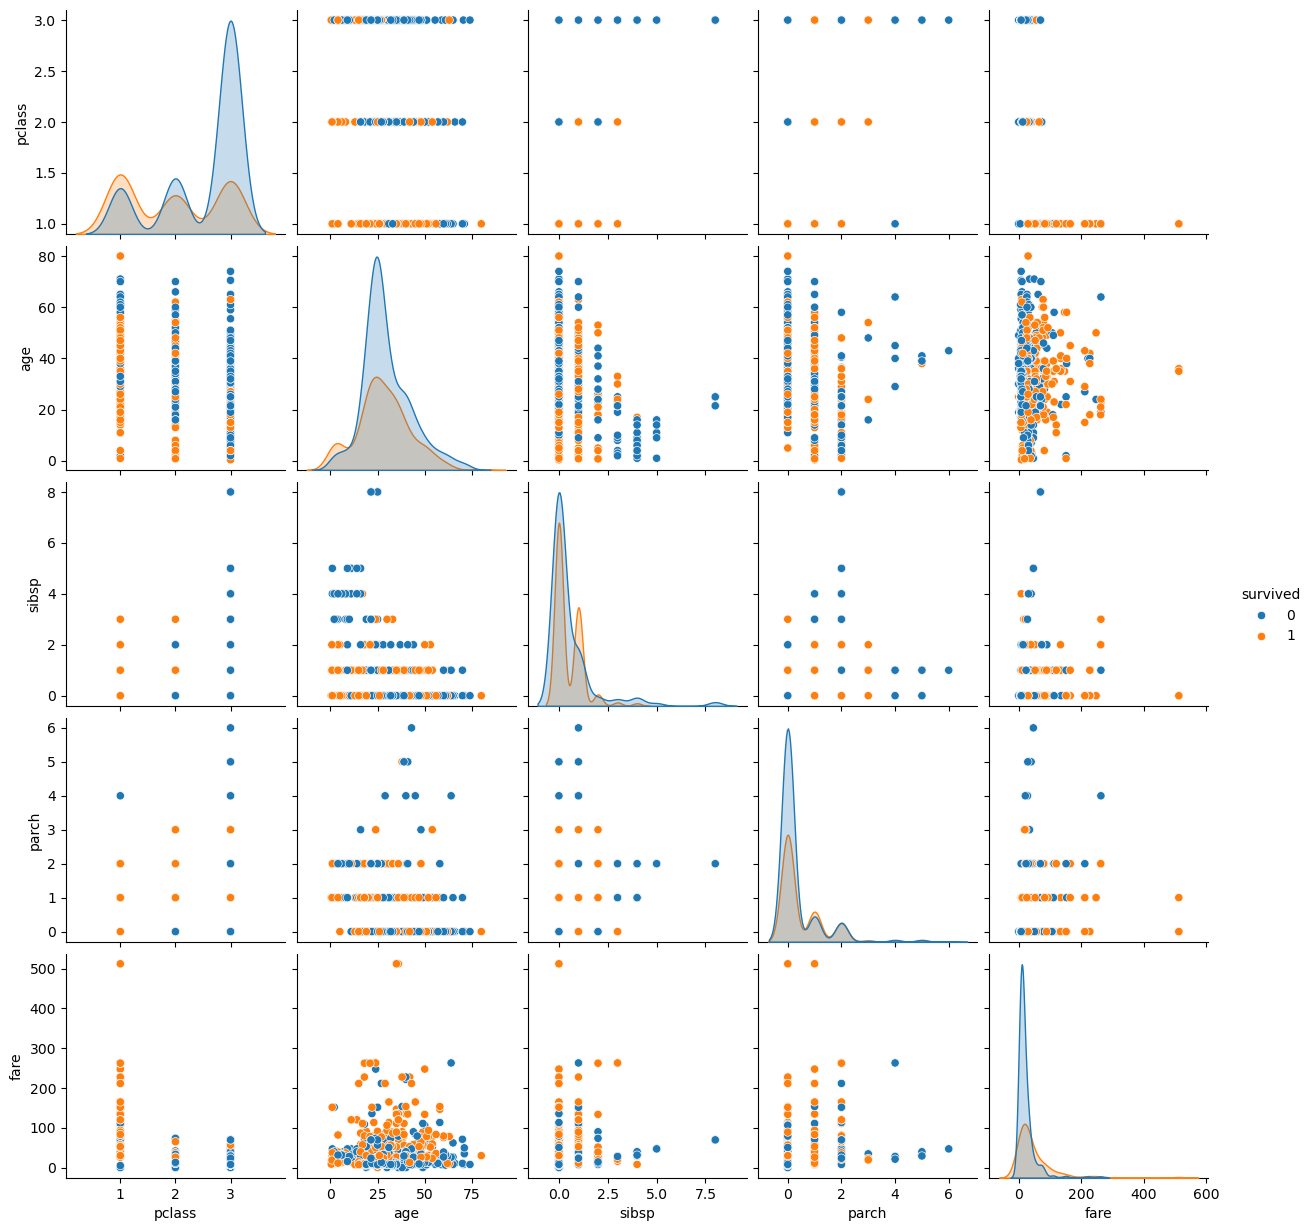

In [42]:
sns.pairplot(df , hue = 'survived')

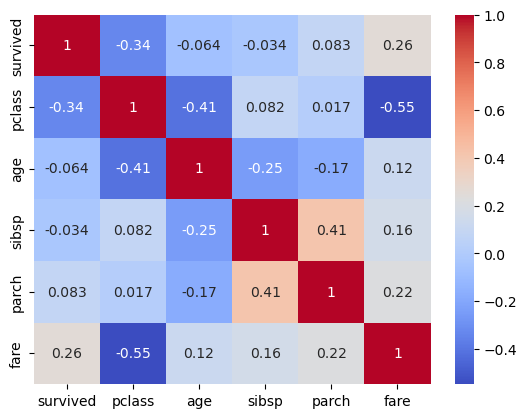

In [44]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [46]:
df.corr(numeric_only=True)['survived']

survived    1.000000
pclass     -0.335549
age        -0.064411
sibsp      -0.034040
parch       0.083151
fare        0.255290
Name: survived, dtype: float64

### Notes :
    - The higer class ---> high survival rate
    - female high survival rate